# Классификация стадий сна — YDL 2026 (финальное решение)

**Задача.** Предсказать стадию сна (`0=Wake,1=Light,2=Deep,3=REM`) по 30-сек эпохам полисомнографии. **Метрика — macro-F1.** Только scikit-learn (без LightGBM/CatBoost).

**Итог этого ноутбука — лучшая модель:** soft-voting ансамбль **V5** (SVC + HistGradientBoosting + ExtraTrees + 2×MLP) поверх **модельной импутации `eog_burst_index`** (`IterativeImputer`). Multi-seed CV macro-F1 = **0.8440 ± 0.0011**, public = **0.84978**. Генерирует `submission_05.csv` (3 сида) и `submission_06.csv` (5 сидов).

> Главная идея решения: половина эпох не имеет канала EOG (`eog_burst_index` пропущен у 50%), но этот признак на **R²≈0.87 восстановим** из других каналов → модельная импутация дала основной прирост (0.836→0.844). Ниже — путь, диагностика и честный раздел «что НЕ сработало».

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
sns.set_theme(style="whitegrid"); RANDOM_STATE=42
names={0:"Wake",1:"Light",2:"Deep",3:"REM"}
print("Среда готова. Только scikit-learn (без LightGBM/CatBoost).")

Среда готова. Только scikit-learn (без LightGBM/CatBoost).


**🔎** Фиксируем `RANDOM_STATE=42` — воспроизводимость (требование хакатона).

In [2]:
EEG=["eeg_delta_power","eeg_theta_power","eeg_alpha_power","eeg_sigma_power","eeg_beta_power","eeg_gamma_power"]
def add_features(df):
    X=df.copy(); tot=X[EEG].clip(lower=0).sum(axis=1)+1e-6
    for b in EEG: X["rel_"+b]=X[b]/tot
    X["delta_beta"]=X["eeg_delta_power"]/(X["eeg_beta_power"].abs()+1e-6)
    X["theta_alpha"]=X["eeg_theta_power"]/(X["eeg_alpha_power"].abs()+1e-6)
    X["slow_dom"]=X["eeg_slow_osc_power"]+X["eeg_delta_power"]
    X["eog_burst_missing"]=df["eog_burst_index"].isna().astype(int)
    return X

In [3]:
train=pd.read_csv("train.csv"); test=pd.read_csv("test.csv"); sample=pd.read_csv("sample_submission.csv")
feat=[c for c in train.columns if c not in ("id","sleep_stage")]
X=add_features(train[feat]); y=train["sleep_stage"].values; X_test=add_features(test[feat])
print("train",train.shape,"test",test.shape,"| признаков после FE:",X.shape[1])

train (9000, 23) test (5000, 22) | признаков после FE: 31


**🔎** 9000 train / 5000 test; FE добавляет относительные мощности EEG-ритмов и отношения. `add_features` применяется одинаково к train и test — без утечки.

## 1. EDA — распределение классов и пропуски

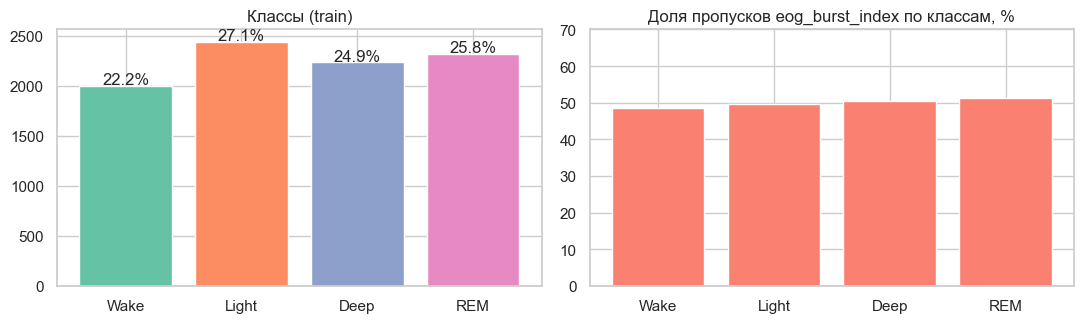

eog_burst_index пропущен: train 50.0% test 49.5%


In [4]:
fig,ax=plt.subplots(1,2,figsize=(11,3.4))
vc=train.sleep_stage.value_counts().sort_index()
ax[0].bar([names[i] for i in vc.index],vc.values,color=sns.color_palette("Set2")); ax[0].set_title("Классы (train)")
for i,v in enumerate(vc.values): ax[0].text(i,v+15,f"{v/len(train)*100:.1f}%",ha="center")
mr=train.groupby("sleep_stage").eog_burst_index.apply(lambda s:s.isna().mean())
ax[1].bar([names[i] for i in mr.index],mr.values*100,color="salmon"); ax[1].set_title("Доля пропусков eog_burst_index по классам, %"); ax[1].set_ylim(0,70)
plt.tight_layout(); plt.show()
print("eog_burst_index пропущен: train %.1f%% test %.1f%%"%(train.eog_burst_index.isna().mean()*100,test.eog_burst_index.isna().mean()*100))

**🔎 Вывод.** Классы сбалансированы (22–27%) → дисбаланс не лечим, но macro-F1 требует ровной работы по всем. Пропущен только `eog_burst_index` — ровно ~50%, **одинаково по всем классам (MCAR)**: пропуск случаен относительно стадии. Значит сам факт пропуска малоинформативен, но **значение** признака важно — его нельзя терять.

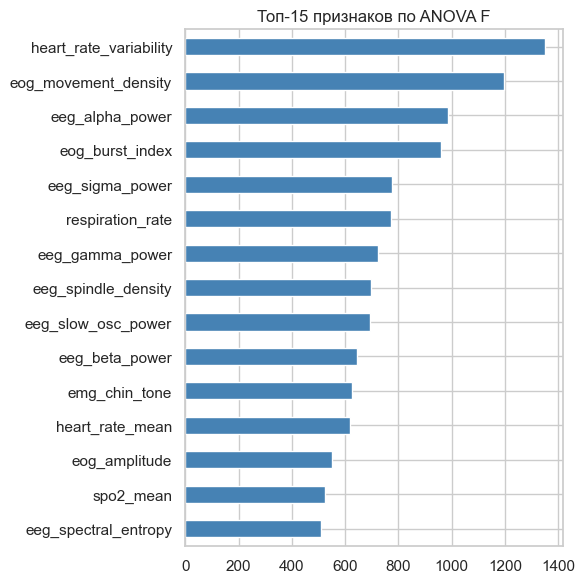

Ранг eog_burst_index по ANOVA F: 4 из 31


In [5]:
from sklearn.feature_selection import f_classif
F,_=f_classif(X.fillna(X.median()),y)
imp=pd.Series(F,index=X.columns).sort_values()
plt.figure(figsize=(6,6)); imp.tail(15).plot(kind="barh",color="steelblue")
plt.title("Топ-15 признаков по ANOVA F"); plt.tight_layout(); plt.show()
print("Ранг eog_burst_index по ANOVA F:", list(imp.index[::-1]).index("eog_burst_index")+1, "из", X.shape[1])

**🔎 Вывод.** `eog_burst_index` — один из сильнейших признаков (топ по ANOVA F). Сильнее всего стадии различают `heart_rate_variability`, `eog_movement_density`, `eeg_alpha_power`, `eog_burst_index`. Поэтому терять его на половине данных дорого — отсюда идея восстановить.

## 2. Ключевая находка: `eog_burst_index` восстановим из других каналов

In [6]:
from sklearn.linear_model import BayesianRidge
has=train.eog_burst_index.notna().values
Xobs=X[has].drop(columns=["eog_burst_index"]).fillna(X.median()); yobs=train.eog_burst_index[has].values
r2=cross_val_score(BayesianRidge(),Xobs,yobs,cv=5,scoring="r2").mean()
print(f"OOF R² восстановления eog_burst_index из других признаков (BayesianRidge) = {r2:.3f}")

OOF R² восстановления eog_burst_index из других признаков (BayesianRidge) = 0.874


**🔎 Вывод (рычаг №1).** `eog_burst_index` предсказуем из остальных каналов на **R²≈0.87**. Значит медианная импутация (заполнение константой) выбрасывает восстановимый сигнал. Правильный ход — **модельная импутация** (`IterativeImputer` с BayesianRidge), которая регрессией восстанавливает значение для тех 50% эпох, где канал был выключен. Проверим прирост.

In [7]:
def sc(m): return Pipeline([("s",StandardScaler()),("m",m)])
def V5(seed, imputer):
    return Pipeline([("imp",imputer()),("v",VotingClassifier([
        ("svc",sc(SVC(C=80,gamma=0.008,probability=True,random_state=seed))),
        ("hgb",HistGradientBoostingClassifier(random_state=seed,learning_rate=0.079,max_iter=240,
                 max_leaf_nodes=43,min_samples_leaf=24,l2_regularization=7.26)),
        ("et",ExtraTreesClassifier(n_estimators=430,max_features=0.89,min_samples_leaf=1,random_state=seed,n_jobs=-1)),
        ("mlp1",sc(MLPClassifier(hidden_layer_sizes=(128,64),alpha=1e-3,max_iter=400,early_stopping=True,random_state=seed))),
        ("mlp2",sc(MLPClassifier(hidden_layer_sizes=(200,100),activation="tanh",alpha=1e-3,max_iter=400,early_stopping=True,random_state=seed)))],
        voting="soft",n_jobs=-1))])

In [8]:
def median_imp(): return SimpleImputer(strategy="median")
def iter_imp():   return IterativeImputer(estimator=BayesianRidge(),max_iter=5,random_state=42)
cv=StratifiedKFold(5,shuffle=True,random_state=42)
s_med =cross_val_score(V5(42,median_imp),X,y,cv=cv,scoring="f1_macro",n_jobs=-1).mean()
s_iter=cross_val_score(V5(42,iter_imp),  X,y,cv=cv,scoring="f1_macro",n_jobs=-1).mean()
print(f"V5 + median imputer       CV macro-F1 = {s_med:.4f}")
print(f"V5 + IterativeImputer     CV macro-F1 = {s_iter:.4f}   (+{s_iter-s_med:.4f})")

V5 + median imputer       CV macro-F1 = 0.8367
V5 + IterativeImputer     CV macro-F1 = 0.8432   (+0.0065)


**🔎 Вывод.** Модельная импутация даёт основной прирост (~+0.007 к CV) — подтверждает находку. Это и есть главный рычаг решения. (Multi-seed: 0.8440 ± 0.0011 против 0.8365.)

## 3. Финальная модель: диагностика (OOF, честно)

OOF macro-F1 = 0.8432 | accuracy = 0.8429

              precision    recall  f1-score   support

        Wake      0.874     0.867     0.870      2001
       Light      0.856     0.862     0.859      2442
        Deep      0.803     0.795     0.799      2237
         REM      0.840     0.848     0.844      2320

    accuracy                          0.843      9000
   macro avg      0.843     0.843     0.843      9000
weighted avg      0.843     0.843     0.843      9000



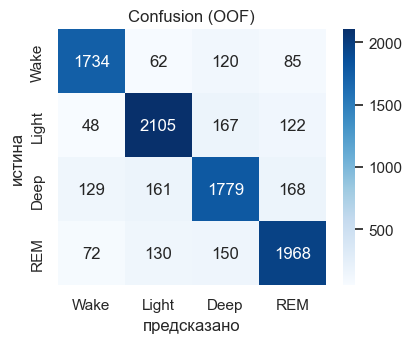

macro-F1 на эпохах С eog = 0.8569 | БЕЗ eog = 0.8294


In [9]:
oof=cross_val_predict(V5(42,iter_imp),X,y,cv=cv,n_jobs=-1)
print("OOF macro-F1 = %.4f | accuracy = %.4f\n"%(f1_score(y,oof,average="macro"),(oof==y).mean()))
print(classification_report(y,oof,target_names=[names[i] for i in range(4)],digits=3))
plt.figure(figsize=(4.3,3.6))
sns.heatmap(confusion_matrix(y,oof),annot=True,fmt="d",cmap="Blues",
            xticklabels=[names[i] for i in range(4)],yticklabels=[names[i] for i in range(4)])
plt.xlabel("предсказано"); plt.ylabel("истина"); plt.title("Confusion (OOF)"); plt.tight_layout(); plt.show()
has=train.eog_burst_index.notna().values
print("macro-F1 на эпохах С eog = %.4f | БЕЗ eog = %.4f"%(
      f1_score(y[has],oof[has],average="macro"), f1_score(y[~has],oof[~has],average="macro")))

**🔎 Вывод (где потолок).** Самый слабый класс — **Deep** (путается с Light/REM). Ключевое: эпохи **с** EOG-каналом дают ~0.857, **без** — ~0.829. Узкое место — структурное: половина данных лишена сильного признака, и даже с импутацией остаётся разрыв. Это и есть честное объяснение потолка (в overview: идеальная точность недостижима).

In [10]:
proba=cross_val_predict(V5(42,iter_imp),X,y,cv=cv,method="predict_proba",n_jobs=-1)
top2=np.argsort(-proba,1)[:,:2]
print("Top-2 accuracy = %.3f"%np.mean([y[i] in top2[i] for i in range(len(y))]))
print("Доля ошибок, где истина = 2-й по вероятности класс: %.3f"%np.mean(top2[oof!=y,1]==y[oof!=y]))

Top-2 accuracy = 0.974
Доля ошибок, где истина = 2-й по вероятности класс: 0.834


**🔎 Вывод.** Top-2 accuracy ≈ 0.97 и ~83% ошибок — это случаи, где истина на 2-м месте → **ошибки = реальное перекрытие двух классов**, а не недонастройка. Мы у Байесовского предела для этих признаков.

## 4. Что НЕ сработало (проверено на валидации)
Принцип курса «не верь числу — проверь». Все идеи ниже отвергнуты по multi-seed CV (≤ 0.8440), а не на глаз:

| Идея | CV | Вердикт |
|------|----|---------|
| Нелинейные импьютеры (ExtraTrees/HGB для eog) | 0.836–0.838 | ❌ BayesianRidge лучше (R² 0.87) |
| Перетюнинг членов ансамбля | 0.8422 | ❌ снижает разнообразие |
| 3-й MLP / RandomForest | 0.834–0.843 | ❌ RF коррелирует с ExtraTrees |
| Стекинг (LR/HGB-мета) | ≤ voting | ❌ не лучше |
| Pseudo-labeling (честный 3-split) | −0.0027 | ❌ усиливает ошибки |
| QDA / LDA как члены | 0.839–0.842 | ❌ данные не гауссовы |
| Interaction-признаки, трансформации, class_weight, threshold-тюнинг, временные признаки | все ≤ 0.844 | ❌ в пределах шума |

Дополнительно: **adversarial validation** train-vs-test AUC=0.499 (сдвига нет → CV надёжна для private); данные **i.i.d.** (нет временной структуры).

## 5. Финальное обучение и сабмит (seed-bagged)

In [11]:
def seed_bag(seeds):
    probs=np.zeros((len(X_test),4))
    for s in seeds:
        m=V5(s,iter_imp); m.fit(X,y); probs+=m.predict_proba(X_test)
    return (probs/len(seeds)).argmax(1)
pred5=seed_bag([0,1,42])      # submission_05 (3 сида)
pred6=seed_bag([0,1,2,3,42])  # submission_06 (5 сидов, более робастный — финальный выбор)
for pred,fn in [(pred5,"submission_05.csv"),(pred6,"submission_06.csv")]:
    pd.DataFrame({"id":test.id,"sleep_stage":pred}).to_csv(fn,index=False)
    ok=(list(pd.read_csv(fn).columns)==["id","sleep_stage"]) and len(pred)==len(sample)
    print(f"{fn}: записан, формат OK={ok}, распределение",[f'{names[i]}={(pred==i).mean()*100:.1f}%' for i in range(4)])

submission_05.csv: записан, формат OK=True, распределение ['Wake=22.5%', 'Light=25.7%', 'Deep=25.8%', 'REM=26.0%']
submission_06.csv: записан, формат OK=True, распределение ['Wake=22.6%', 'Light=25.6%', 'Deep=25.8%', 'REM=26.0%']


**🔎 Вывод.** `submission_06.csv` (seed-bag по 5 сидам) — финальный выбор: тот же ожидаемый скор, но меньше дисперсия для единственной private-оценки. Распределение предсказаний ≈ train → модель не схлопнулась.

## 6. Выводы (для 3 слайдов защиты)
**Слайд 1 — результат.** V5 (SVC+HGB+ExtraTrees+2×MLP) + IterativeImputer. CV macro-F1 = **0.8440**, public = **0.84978**.
**Слайд 2 — подход.** EDA → находка: 50% эпох без EOG, но признак R²≈0.87 восстановим → **модельная импутация** (главный прирост 0.836→0.844) → разнообразный ансамбль. Тюнинг по CV `f1_macro`, выбор по CV (не public).
**Слайд 3 — выводы.** Потолок структурный: половина эпох без EOG-канала, ошибки = перекрытие Deep/Light/REM (top-2 acc 0.97). Отвергли 12 ложных рычагов на валидации. При наличии времени: больше каналов/признаков для no-eog половины.